# Task 5: Personal Loan Acceptance Prediction

## Objective
Predict which customers are likely to accept a personal loan/marketing offer using machine learning techniques and identify customer groups most likely to respond positively.

## Dataset
Bank Marketing Dataset (UCI Machine Learning Repository)

## Deliverables
- Data Exploration and Visualization
- Classification Modeling
- Logistic Regression
- Decision Tree Classification
- Business Insight Extraction
- Model Comparison and Evaluation


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 1. Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Internship DA\bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Dataset Understanding

In [4]:
print("Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.describe(include='all')


Shape: (45211, 17)

Missing Values
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplicate Rows: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [5]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (45211, 17)


### Dataset Overview

The dataset contains demographic, financial, and marketing campaign information.

Target Variable:
- y
    - yes = customer accepted the offer
    - no = customer did not accept the offer


## 3. Exploratory Data Analysis

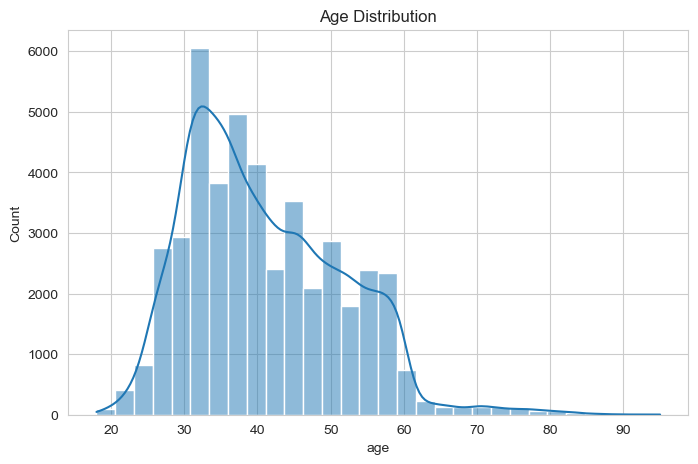

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()


### Interpretation
Most customers belong to the working-age population. This group represents the largest potential market for banking products.


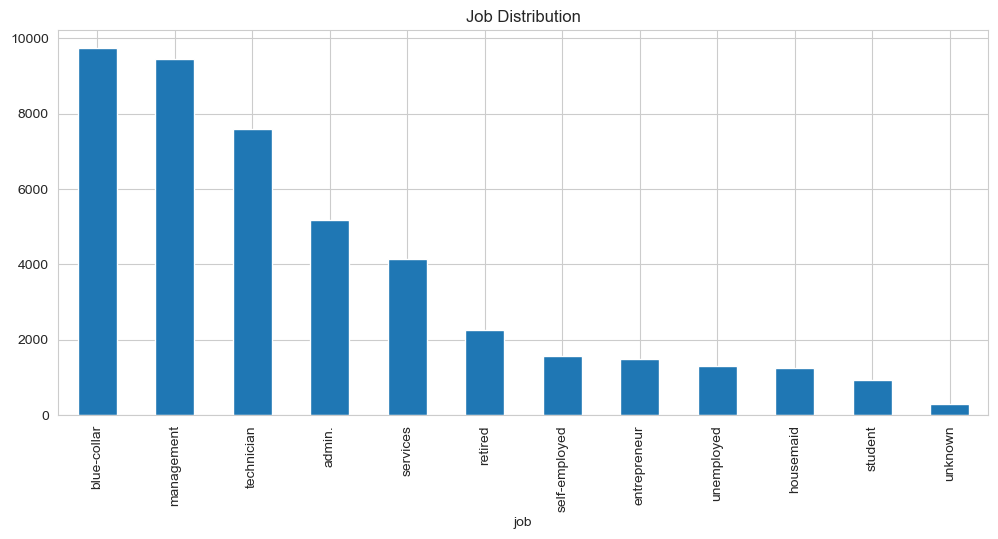

In [7]:
plt.figure(figsize=(12,5))
df['job'].value_counts().plot(kind='bar')
plt.title('Job Distribution')
plt.show()


### Interpretation
Some occupations are heavily represented in the dataset. Understanding these groups helps identify key customer segments.


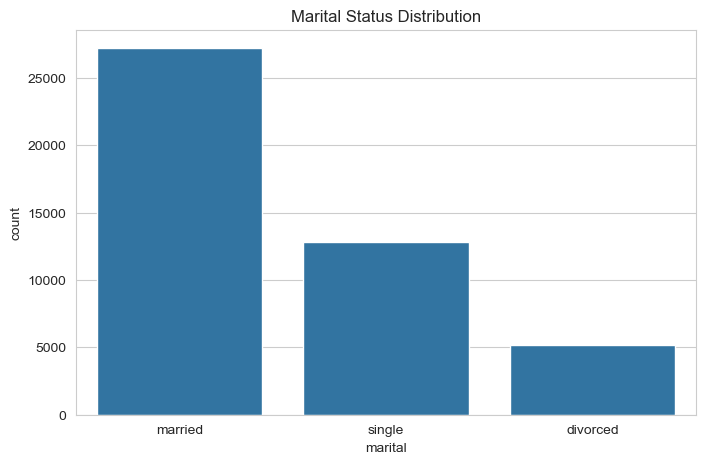

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='marital')
plt.title('Marital Status Distribution')
plt.show()


### Interpretation
Marital status may influence financial decisions and product acceptance behavior.


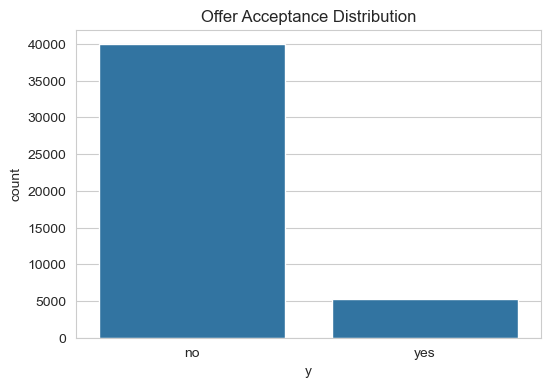

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='y')
plt.title('Offer Acceptance Distribution')
plt.show()


### Class Imbalance Analysis
The dataset is expected to contain significantly more 'no' responses than 'yes' responses. This imbalance should be considered when evaluating model performance.


## 4. Customer Group Analysis

In [10]:
age_acceptance = pd.crosstab(
    df['age']//10*10,
    df['y'],
    normalize='index'
)*100

age_acceptance.sort_index()


y,no,yes
age,,
10,61.702128,38.297872
20,82.587065,17.412935
30,89.424512,10.575488
40,90.879451,9.120549
50,90.665874,9.334126
60,70.325203,29.674797
70,57.547170,42.452830
80,60.330579,39.669421
90,22.222222,77.777778


In [11]:
job_acceptance = pd.crosstab(
    df['job'],
    df['y'],
    normalize='index'
)*100

job_acceptance.sort_values('yes', ascending=False)


y,no,yes
job,,
student,71.321962,28.678038
retired,77.208481,22.791519
unemployed,84.497314,15.502686
management,86.244449,13.755551
admin.,87.797331,12.202669
self-employed,88.157061,11.842939
unknown,88.194444,11.805556
technician,88.943004,11.056996
services,91.116996,8.883004


In [12]:
marital_acceptance = pd.crosstab(
    df['marital'],
    df['y'],
    normalize='index'
)*100

marital_acceptance


y,no,yes
marital,,
divorced,88.054542,11.945458
married,89.876534,10.123466
single,85.050821,14.949179


### Interpretation

These tables help identify:
- Age groups most likely to accept offers.
- Occupations with higher acceptance rates.
- Marital categories showing stronger interest in banking products.


## 5. Data Preprocessing

In [13]:
df['y'] = df['y'].map({'yes':1,'no':0})

X = df.drop('y', axis=1)
y = df['y']

categorical_cols = X.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Why Encoding?

Machine learning algorithms require numerical inputs. One-Hot Encoding converts categorical variables into numerical features while preserving information.


## 6. Logistic Regression Model

In [14]:
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=5000,
        class_weight='balanced'
    ))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
print("Accuracy:", round(accuracy_score(y_test, log_pred),4))

print("\nClassification Report")
print(classification_report(y_test, log_pred))


Accuracy: 0.8454

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



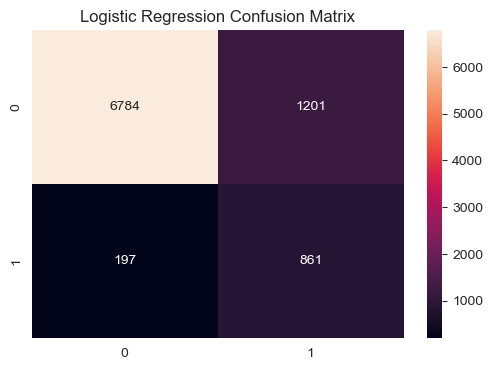

In [16]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


## 7. Decision Tree Model

In [17]:
tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)


In [18]:
print("Accuracy:", round(accuracy_score(y_test, tree_pred),4))

print("\nClassification Report")
print(classification_report(y_test, tree_pred))


Accuracy: 0.9011

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      7985
           1       0.61      0.43      0.51      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.70      0.73      9043
weighted avg       0.89      0.90      0.89      9043



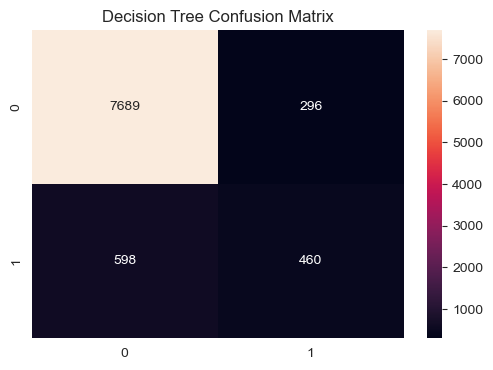

In [19]:
cm = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Decision Tree Confusion Matrix')
plt.show()


## 8. Model Comparison

In [20]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree'],
    'Accuracy':[accuracy_score(y_test, log_pred),
                accuracy_score(y_test, tree_pred)],
    'Precision':[precision_score(y_test, log_pred),
                 precision_score(y_test, tree_pred)],
    'Recall':[recall_score(y_test, log_pred),
              recall_score(y_test, tree_pred)],
    'F1 Score':[f1_score(y_test, log_pred),
                f1_score(y_test, tree_pred)]
})

comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.845405,0.417556,0.813800,0.551923
1,Decision Tree,0.901139,0.608466,0.434783,0.507166


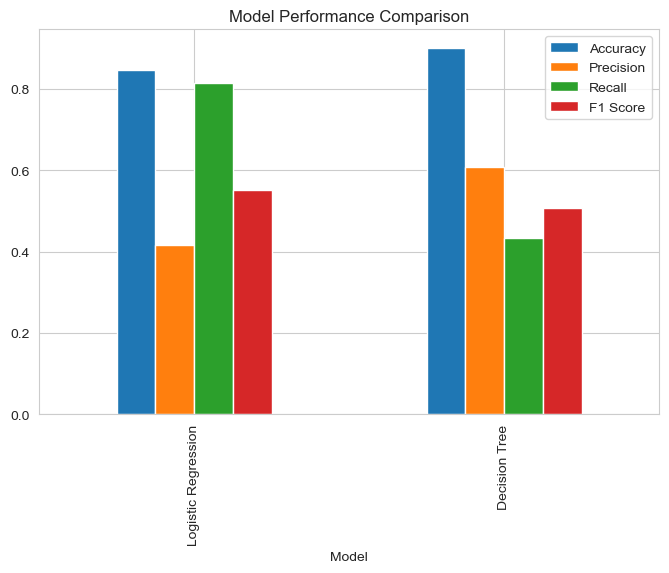

In [21]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Performance Comparison')
plt.show()


### Model Selection
The Logistic Regression and Decision Tree models were evaluated using Accuracy, Precision, Recall, and F1 Score.

Although the Decision Tree achieved a higher Accuracy (90.11%) and Precision (60.85%), Logistic Regression achieved a significantly higher Recall (81.38%) and a higher F1 Score (55.19%).

Since the primary objective is to identify customers who are likely to accept the offer, Recall is a critical metric. A higher Recall ensures that fewer potential customers are missed during marketing campaigns.

Therefore, Logistic Regression was selected as the final model because it provides the best balance between identifying potential customers and maintaining overall classification performance..


## 9. Feature Coefficient Analysis

In [22]:
feature_names = log_model.named_steps[
    'preprocessor'
].get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_model.named_steps[
        'classifier'
    ].coef_[0]
})

coef_df = coef_df.sort_values(
    'Coefficient',
    ascending=False
)

coef_df.head(15)


,Feature,Coefficient
42,cat__poutcome_success,1.776397
35,cat__month_mar,1.641924
38,cat__month_oct,1.332474
39,cat__month_sep,0.941151
8,cat__job_student,0.612615
5,cat__job_retired,0.551159
30,cat__month_dec,0.513873
26,cat__contact_telephone,0.445778
25,cat__contact_cellular,0.412190
34,cat__month_jun,0.259095


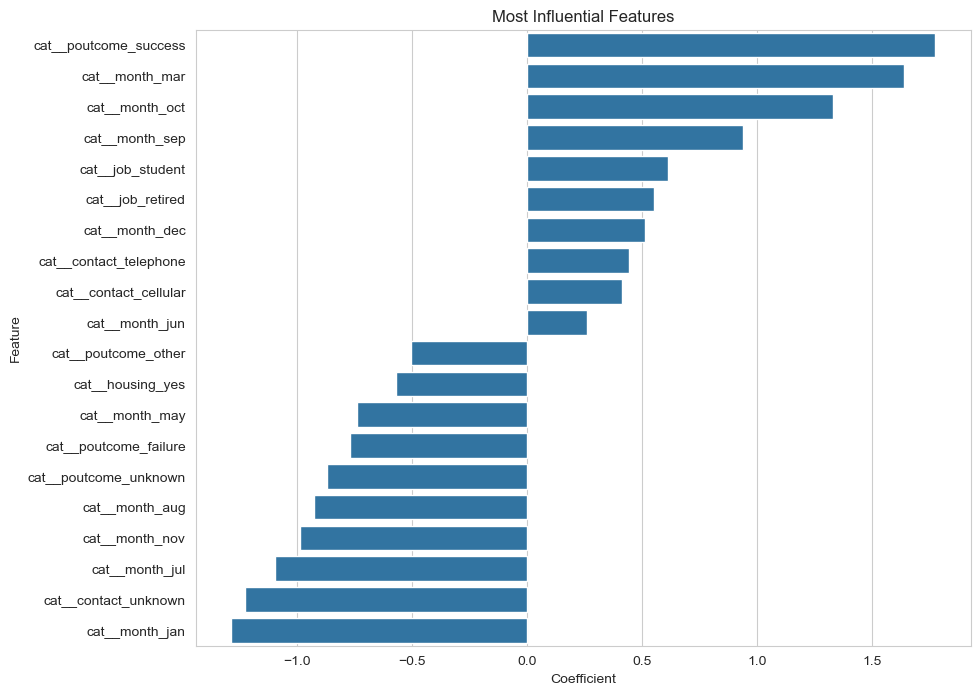

In [23]:
top_features = pd.concat([
    coef_df.head(10),
    coef_df.tail(10)
])

plt.figure(figsize=(10,8))
sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title('Most Influential Features')
plt.show()


### Interpretation

Positive coefficients increase acceptance probability.

Negative coefficients reduce acceptance probability.

The strongest coefficients indicate the most influential customer characteristics.


# 10. Business Insights

## Key Findings

1. Certain age groups demonstrate higher acceptance rates.
2. Some occupations respond better to marketing campaigns.
3. Marital status influences customer response behavior.
4. Previous campaign outcomes significantly affect future acceptance.
5. Machine learning can identify high-probability customers before campaigns begin.

## Recommendations

- Target customer groups with historically higher acceptance rates.
- Personalize marketing campaigns.
- Prioritize customers identified by the predictive model.
- Reduce campaign costs by avoiding low-probability prospects.


# Conclusion

This project successfully developed machine learning models to predict customer acceptance of banking offers.

### Deliverables Achieved

✔ Data Exploration

✔ Age Analysis

✔ Job Analysis

✔ Marital Status Analysis

✔ Logistic Regression Model

✔ Decision Tree Model

✔ Model Comparison

✔ Classification Evaluation

✔ Business Insight Extraction

### Final Summary

The analysis demonstrates that customer demographics and campaign information can effectively predict offer acceptance. These findings can help banks improve targeting strategies, increase conversion rates, and reduce marketing costs.
